# Data Preparation

In this notebook, we are setting up the data pipeline for the deep image watermarking project.

In [2]:
import os
import urllib.request
import random
import zipfile
import matplotlib.pyplot as plt
import hashlib
import json
from PIL import Image

import sys
sys.path.append(os.path.abspath('..'))
from src.data import get_dataloaders, get_dataset_stats
from src.utils import set_seed

To ensure our experiments are fully reproducible, we will set a global random seed across Python's `random`, `numpy`, and `PyTorch` environments.

In [3]:
set_seed()

### Fetching the Data

We will use the **COCO 2017 Validation** dataset, which provides a variety of images. The functions below automate downloading the dataset, extracting the images to the `data/raw/` directory and displaying a small subset to verify the download.

In [4]:
def download_dataset(dir: str, n: int = 5000):
    """
    Downloads the COCO 2017 validation dataset and selects `n` images from it.
    
    Args:
        dir (str): The path to the folder where data should be downloaded.
        n (int): Number of images to select. Defaults to 5000.
    """
    os.makedirs(dir, exist_ok=True)
    
    coco_val_url = "http://images.cocodataset.org/zips/val2017.zip"
    zip_path = os.path.join(dir, "val2017.zip")
    extract_dir = os.path.join(dir, "val2017")

    if not os.path.exists(extract_dir):
        if not os.path.exists(zip_path):
            print("Downloading COCO val2017 dataset...")
            urllib.request.urlretrieve(coco_val_url, zip_path)
            print("Download completed.")
        
        print("Extracting images...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(dir)
        print("Extraction completed.")
        
        if os.path.exists(zip_path):
            os.remove(zip_path)
    else:
        print("Directory already exists. Skipping download and extraction.")

    image_files = sorted([f for f in os.listdir(extract_dir) if f.endswith('.jpg')])
    selected_images = image_files[:n]
    
    print(f"Success! {len(selected_images)} images saved in: {os.path.abspath(extract_dir)}")

def plot_images(dir: str, n: int = 30):
    """
    Displays `n` random images from the specified directory in a grid.
    
    Args:
        dir (str): Directory containing the images.
        n (int): Number of images to display. Defaults to 30.
    """
    if not os.path.exists(dir):
        print(f"Directory {dir} does not exist.")
        return

    all_images = [f for f in os.listdir(dir) if f.endswith('.jpg')]
    if not all_images:
        print(f"No JPG images found in {dir}.")
        return

    n = min(n, len(all_images))
    selected_images = random.sample(all_images, n)
    
    cols = 5
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    axes = axes.flatten()
    
    for i, img_name in enumerate(selected_images):
        img_path = os.path.join(dir, img_name)
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

We can now execute the download function and visualize a random sample to confirm the data is stored locally.

Directory already exists. Skipping download and extraction.
Success! 5000 images saved in: c:\Users\david\Desktop\DeepImageWatermarking\data\raw\val2017


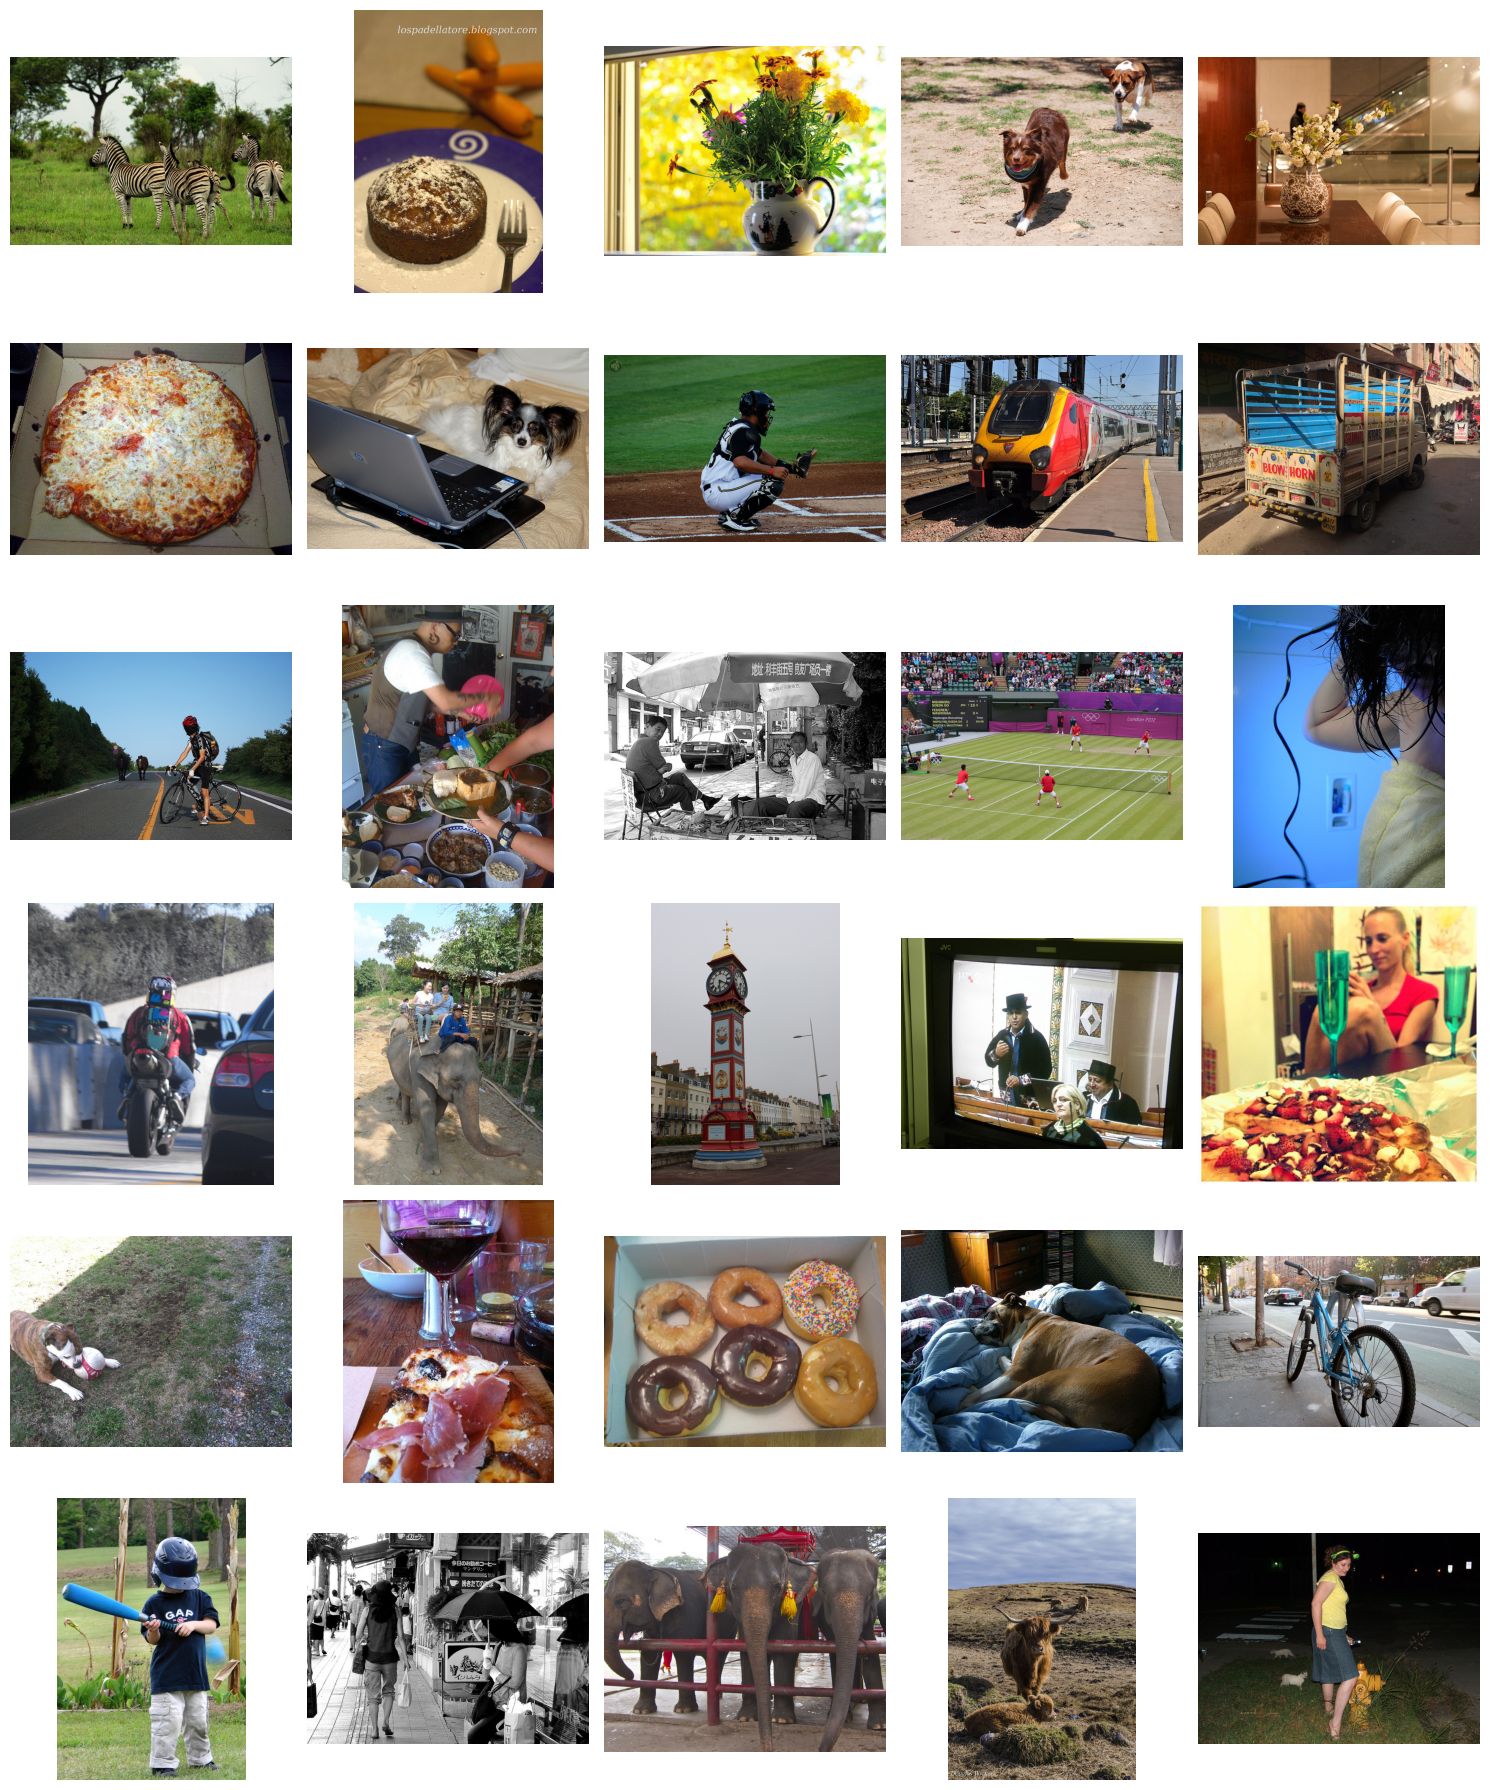

In [5]:
download_dataset('../data/raw/')
plot_images('../data/raw/val2017')

### Dataset Cleanup

Data quality issues like corrupted files, small images or exact duplicates can degrade model performance. The `clean_dataset` function iterates through the downloaded images and removes:
1. Files that cannot be opened by the PIL library.
2. Images with dimensions smaller than the required 128x128 pixels.
3. Exact file duplicates.

In [6]:
def clean_dataset(dir: str, min_size: int = 128):
    """
    Cleans the dataset by removing invalid, corrupted, extremely small or duplicate images.
    
    Args:
        dir (str): The directory containing the images.
        min_size (int): Minimum required dimension (width or height). Defaults to 128.
    """
    if not os.path.exists(dir):
        print(f"Directory {dir} does not exist.")
        return

    all_images = [f for f in os.listdir(dir) if f.endswith('.jpg')]
    print(f"Starting dataset cleanup...")
    
    removed_corrupted = 0
    removed_small = 0
    removed_duplicates = 0
    seen_hashes = set()
    
    for img_name in all_images:
        img_path = os.path.join(dir, img_name)
        
        try:
            with Image.open(img_path) as img:
                img.verify()
                
                with Image.open(img_path) as img_check:
                    width, height = img_check.size
                    if width < min_size or height < min_size:
                        os.remove(img_path)
                        removed_small += 1
                        continue

            with open(img_path, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()
                
            if file_hash in seen_hashes:
                os.remove(img_path)
                removed_duplicates += 1
            else:
                seen_hashes.add(file_hash)
                 
        except (IOError, SyntaxError) as e:
            os.remove(img_path)
            removed_corrupted += 1
            
    print("Cleanup results:")
    print(f" - Corrupted: {removed_corrupted}")
    print(f" - Too small: {removed_small}")
    print(f" - Duplicates: {removed_duplicates}")
    
    remaining = len([f for f in os.listdir(dir) if f.endswith('.jpg')])
    print(f"Remaining valid images: {remaining}")

In [7]:
clean_dataset('../data/raw/val2017', min_size=128)

Starting dataset cleanup...
Cleanup results:
 - Corrupted: 0
 - Too small: 0
 - Duplicates: 0
Remaining valid images: 5000


### Train / Validation / Test Split

We need to divide our data into **training**, **validation** and **testing** sets. 
We will shuffle the images and divide them using the defined ratio. Instead of maintaining multiple physical folders, we will store the file assignments in a `splits.json` file. This approach is more efficient and simplifies integration with the custom PyTorch `Dataset` loading object.

In [8]:
def create_splits(dir: str, output_json: str = '../data/splits.json',
                  train_ratio: float = 0.8, val_ratio: float = 0.1, test_ratio: float = 0.1):
    """
    Splits dataset into train, validation and test sets and saves the mapping to a JSON file.
    
    Args:
        dir (str): Directory containing the images.
        output_json (str): Path to save the resulting JSON file. Defaults to '../data/splits.json'.
        train_ratio (float): Ratio for training set. Defaults to 0.8.
        val_ratio (float): Ratio for validation set. Defaults to 0.1.
        test_ratio (float): Ratio for test set. Defaults to 0.1.
    """
    if not os.path.exists(dir):
        print(f"Directory {dir} does not exist.")
        return

    folder_name = os.path.basename(dir.rstrip('/\\'))
    all_images = [f"{folder_name}/{f}" for f in os.listdir(dir) if f.endswith('.jpg')]
    
    if len(all_images) == 0:
        print("No images found.")
        return

    total_ratio = train_ratio + val_ratio + test_ratio
    if abs(total_ratio - 1.0) > 1e-5:
        print(f"Warning: Ratios sum to {total_ratio}.")
        return

    random.shuffle(all_images)
    
    num_images = len(all_images)
    num_train = int(num_images * train_ratio)
    num_val = int(num_images * val_ratio)
    
    train_images = all_images[:num_train]
    val_images = all_images[num_train:num_train + num_val]
    test_images = all_images[num_train + num_val:]
    
    splits = {
        "train": train_images,
        "val": val_images,
        "test": test_images
    }
    
    os.makedirs(os.path.dirname(output_json), exist_ok=True)
    
    with open(output_json, 'w') as f:
        json.dump(splits, f, indent=4)
        
    print(f"Dataset split saved to: {output_json}")
    print(f"Total: {num_images} | Train: {len(train_images)} | Val: {len(val_images)} | Test: {len(test_images)}")

In [9]:
create_splits('../data/raw/val2017', output_json='../data/splits.json')

Dataset split saved to: ../data/splits.json
Total: 5000 | Train: 4000 | Val: 500 | Test: 500


### DataLoaders and Summary

After the data is split, we can integrate the PyTorch components developed in `src.data`. This script provides `DataLoader` initialization and a custom dataset wrapper that handles standardizing, scaling and tensor normalization.

We will fetch the basic distribution stats, load a batch and verify that the output tensor shape matches our architectural requirements (e.g. `[BatchSize, Channels, Width, Height]`).

In [10]:
data_dir = '../data'
splits_file = '../data/splits.json'

print("Dataset Stats:")
stats = get_dataset_stats(data_dir, splits_file)
for key, value in stats.items():
    print(f"  {key}: {value}")

train_loader, val_loader, test_loader = get_dataloaders(data_dir, splits_file, batch_size=32)

Dataset Stats:
  Number of train images: 4000
  Number of val images: 500
  Number of test images: 500
  Image shape: [3, 128, 128]
  Image value range: [0.0, 1.0]


The statistics confirm our data pipeline is fully operational.